In [11]:
import numpy as np
import matplotlib.pyplot as plt

from weather.config import WeatherConfig
from weather.dataset import build_dataset
from weather.normalization import normalize_global

from mlp.mlp import MLP
from mlp.utils import (
    plot_loss,
    regression_report,
    accuracy_within_tolerance,
)


In [12]:
SEED = 42
np.random.seed(SEED)

experiments = {
    "temperature_regression": {
        "task": "regression",
        # "losses": ["mse"],
        # "losses": ["mae"],
        "losses": ["huber"],
        # "activation": "sigmoid",
        "activation": "gelu",
        # "learning_rate": 0.003,
        "learning_rate": 0.01,
        # "hidden_layers": [64, 128, 128, 64, 64, 64],
        "hidden_layers": [32, 64],
        # "epochs": [800],
        "epochs": [400],
        "optimizer": "momentum",
        "adaptive_lr": True,
        "batching": {
            "minibatch_auto": {
                "batch_size": "auto",
                "shuffle": False,
            },
        },
        "early_stopping": True,
        "patience": 50,
    }
}


In [13]:
base_cfg = WeatherConfig(
    data_dir="../data",
    split="train",
    target="temperature",
    window_size=3,
    skip_day=True,
    normalization="global",
    encode_wind_direction=True,
    max_missing_ratio_per_day=0.3,
)

# NOTE: Best so far temperature inputs: temperature, humidity, pressure
base_cfg.input_variables = [
    "temperature",
    "humidity",
    "pressure",
    # "wind_speed",
    # "wind_direction",
]

base_cfg.aggregations = {
    "temperature": ["mean", "min", "max"],
    "humidity": ["mean", "min", "max"],
    "pressure": ["mean", "min", "max"],
    # "wind_speed": ["mean", "max"],
    # "wind_direction": ["mean"],
}

# base_cfg.cities = [
#     "Vancouver", "Portland", "San Francisco", "Seattle",
#     "Phoenix", "Albuquerque", "Denver", "San Antonio", "Dallas", "Houston",
#     "Kansas City", "Minneapolis", "Saint Louis", "Chicago", "Nashville",
#     "Indianapolis", "Atlanta", "Detroit", "Jacksonville", "Charlotte",
#     "Miami", "Pittsburgh", "Toronto", "Philadelphia", "New York",
#     "Montreal", "Boston",
#     "Beersheba", "Tel Aviv District", "Eilat", "Haifa", "Nahariyya", "Jerusalem"
# ]

# base_cfg.cities = ["Vancouver", "Portland", "San Francisco", "Seattle"]
# base_cfg.cities = ["Vancouver", "Portland"]
base_cfg.cities = ["Vancouver"]


In [14]:
from copy import deepcopy
import numpy as np
from weather.dataset import build_dataset
from weather.normalization import normalize_global

results = {}

# for mode in ["flatten", "aggregate"]:
for mode in ["flatten"]:
    print("\n" + "=" * 80)
    print(f"WINDOW AGGREGATION MODE: {mode.upper()}")
    print("=" * 80)

    cfg = deepcopy(base_cfg)
    cfg.window_aggregation = mode

    # --- TRAIN DATASET ---
    print("\nBuilding TRAIN dataset...")
    cfg.split = "train"
    X_train, y_train = build_dataset(cfg, verbose=False)
    X_train, mu, sigma = normalize_global(X_train)

    # --- TEST DATASET ---
    print("\nBuilding TEST dataset...")
    cfg.split = "test"
    X_test, y_test = build_dataset(cfg, verbose=False)
    X_test = (X_test - mu) / sigma  # ta sama normalizacja

    print(f"Train shape: X={X_train.shape}, y={y_train.shape}")
    print(f"Test  shape: X={X_test.shape}, y={y_test.shape}")




WINDOW AGGREGATION MODE: FLATTEN

Building TRAIN dataset...


Vancouver | windows: 100%|██████████| 1518/1518 [00:03<00:00, 411.66it/s]



Building TEST dataset...


Vancouver | windows: 100%|██████████| 361/361 [00:00<00:00, 399.81it/s]

Train shape: X=(1270, 27), y=(1270, 1)
Test  shape: X=(328, 27), y=(328, 1)



--- EXPERIMENT: temperature_regression ---

Loss=huber, Epochs=400, Activation=gelu, Optimizer=momentum
>>> Initializing MLP...
Layer sizes: [27, 32, 64, 1], Task: regression, Activation: gelu, Optimizer: momentum
>>> Version 16 (mini-batch + early stopping)...


Training:  38%|███▊      | 153/400 [00:02<00:04, 60.93it/s, acc=n/a, loss=1.2330, lr=0.00214874]


Early stopping at epoch 154, best val_loss=1.392676 after 50 epochs without improvement.
Training finished in 2.51 seconds
Test MAE           : 1.9901
Test MSE           : 6.4496
Accuracy |err|≤2°C : 0.6037
Accuracy |err|≤2.5°C : 0.6982


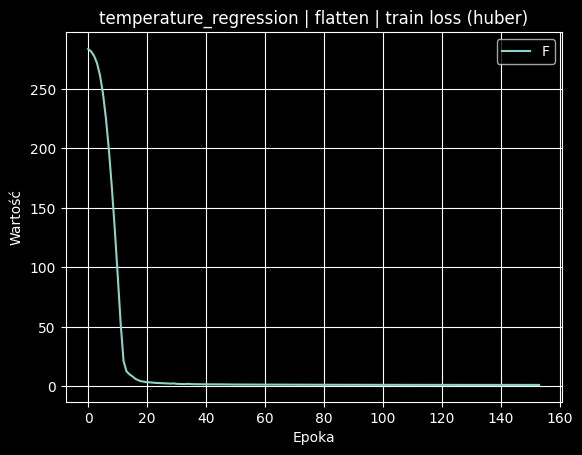

In [15]:
from mlp.mlp import MLP
from mlp.utils import plot_loss

# %pdb on

for mode in ["flatten"]:
    results[mode] = {}

    for exp_name, exp in experiments.items():
        print(f"\n--- EXPERIMENT: {exp_name} ---")

        n_inputs = X_train.shape[1]

        for loss_name in exp["losses"]:
            for n_epochs in exp["epochs"]:

                print(
                    f"\nLoss={loss_name}, "
                    f"Epochs={n_epochs}, "
                    f"Activation={exp['activation']}, "
                    f"Optimizer={exp['optimizer']}"
                )

                model = MLP(
                    layer_sizes=[n_inputs, *exp["hidden_layers"], 1],
                    task=exp["task"],
                    activation=exp["activation"],
                    learning_rate=exp["learning_rate"],
                    seed=SEED,
                    loss=loss_name,
                    optimizer=exp["optimizer"],
                    adaptive_lr=exp["adaptive_lr"],
                )

                history, _, _ = model.fit(
                    X_train,
                    y_train,
                    epochs=n_epochs,
                    batch_size=exp["batching"]["minibatch_auto"]["batch_size"],
                    shuffle=exp["batching"]["minibatch_auto"]["shuffle"],
                    verbose=True,
                    use_tqdm=True,
                    early_stopping=exp["early_stopping"],
                    patience=exp["patience"],
                )

                # ===================== TEST EVALUATION =====================
                y_pred_test = model.predict(X_test)

                metrics = regression_report(y_test, y_pred_test)
                metrics["accuracy_2C"] = accuracy_within_tolerance(y_test, y_pred_test, tol=2.0)
                metrics["accuracy_2.5C"] = accuracy_within_tolerance(y_test, y_pred_test, tol=2.5)

                print(f"Test MAE           : {metrics['mae']:.4f}")
                print(f"Test MSE           : {metrics['mse']:.4f}")
                print(f"Accuracy |err|≤2°C : {metrics['accuracy_2C']:.4f}")
                print(f"Accuracy |err|≤2.5°C : {metrics['accuracy_2.5C']:.4f}")

                # results[mode][exp_name][f"{loss_name}_{n_epochs}"] = {
                #     "train_loss": history,
                #     **metrics,
                # }

                # ===================== PLOTS =====================
                plot_loss(
                    history,
                    title=f"{exp_name} | {mode} | train loss ({loss_name})"
                )

# %pdb off
